# Supplementary Figure S3: Strong-Squeezing Lattice Entropy

Supplementary Figure S3 shows that a fixed undecorated graph enters a graph-controlled, lattice-scale entropy regime as the squeezing parameter is reduced.

This figure includes:

* a single entropy-versus-region-size panel for several values of $\mu$

## Import Dependencies and Set Parameters

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from __future__ import annotations

import hashlib
import json
import os
import pickle
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
from tqdm.auto import tqdm

import loadconfig as loco
from graph2grav.analysis import Analysis
from graph2grav.analytic_entropies import periodic_CFT_entropy
from graph2grav.figure_hashing import save_figure_with_hash
from graph2grav.graphs.standard import crosslinked_tree, make_tree_periodic

config = loco.reload()
plt.rcParams.update({"figure.dpi": 120})
subfigure_label_fontsize = config["subfigure-label"]["font"]["size"]

FIGURE_PATH = Path("figures/supplementary-figure_strong-squeezing-lattice-entropy.pdf")
CACHE_DIR = Path("outputs/notebook_cache/S05_strong_squeezing_lattice_entropy")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = 2
USE_NOTEBOOK_CACHE = True
CLEAR_NOTEBOOK_CACHE = False

DEPTH = 6
COUPLING_TIME = 1.0
MU_VALUES = (1.0, 0.1, 0.01, 0.001, 0.0001)
COLORMAP = plt.get_cmap("viridis")
MU_COLORS = {
    mu: COLORMAP(value)
    for mu, value in zip(MU_VALUES, np.linspace(0.15, 0.86, len(MU_VALUES)))
}




## Define Helpers

Build the fixed periodic MERA graph, cache entropy curves, and format the squeezing labels.

In [2]:
def undecorated_mera(depth):
    return make_tree_periodic(crosslinked_tree(depth), remove_nodes=False)


def entropy_cache_key(mu):
    return {
        "cache_version": CACHE_VERSION,
        "depth": int(DEPTH),
        "mu": float(mu),
        "coupling_time": float(COUPLING_TIME),
        "graph_kind": "undecorated_periodic_mera",
    }


def entropy_cache_path(mu):
    digest = hashlib.sha256(json.dumps(entropy_cache_key(mu), sort_keys=True).encode("utf-8")).hexdigest()[:16]
    return CACHE_DIR / f"entropy_{digest}.pkl"


def entropy_row(mu):
    graph = undecorated_mera(DEPTH)
    analysis = Analysis(
        graph,
        couplingtime=COUPLING_TIME,
        global_presqueeze=float(mu),
        is_decorated=False,
    )
    central_charge, offset = analysis.fit_central_charge()
    region_sizes = np.asarray(analysis.region_sizes, dtype=float)
    entropies = np.asarray(analysis.boundary_entropies, dtype=float)
    entropies[0] = 0.0
    entropies[-1] = 0.0
    fit = np.full_like(entropies, np.nan, dtype=float)
    interior = (region_sizes > 0) & (region_sizes < analysis.boundary_length)
    fit[interior] = periodic_CFT_entropy(
        region_sizes[interior],
        analysis.boundary_length,
        central_charge=central_charge,
        offset=offset,
    )
    return {
        "mu": float(mu),
        "depth": int(DEPTH),
        "boundary_length": int(analysis.boundary_length),
        "region_sizes": region_sizes,
        "entropies": entropies,
        "fit": fit,
        "residual": entropies - fit,
        "central_charge": float(central_charge),
        "central_charge_stderr": float(analysis.central_charge_stderr),
        "offset": float(offset),
    }


def cached_entropy_row(mu):
    cache_path = entropy_cache_path(mu)
    key = entropy_cache_key(mu)
    if CLEAR_NOTEBOOK_CACHE and cache_path.exists():
        cache_path.unlink()
    if USE_NOTEBOOK_CACHE and cache_path.exists():
        with cache_path.open("rb") as handle:
            cached = pickle.load(handle)
        if cached.get("cache_key") == key:
            return cached["row"]
    row = entropy_row(mu)
    if USE_NOTEBOOK_CACHE:
        with cache_path.open("wb") as handle:
            pickle.dump({"cache_key": key, "row": row}, handle)
    return row


rows = [cached_entropy_row(mu) for mu in tqdm(MU_VALUES, desc="A9 entropy curves")]
rows_by_mu = {row["mu"]: row for row in rows}
REFERENCE_ROW = rows_by_mu[MU_VALUES[0]]


A9 entropy curves:   0%|          | 0/5 [00:00<?, ?it/s]

## Make Figure

Plot entropy curves across squeezing values and save the supplementary figure.

Saved figure to figures/supplementary-figure_strong-squeezing-lattice-entropy.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=d24e9875e9aea9f3, data_hash=daa25173f6d49eea, size=21572 bytes.


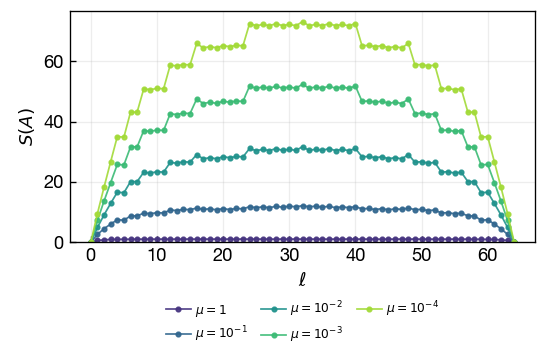

{'depth': 6,
 'boundary_length': 64,
 'mu_values': (1.0, 0.1, 0.01, 0.001, 0.0001),
 'central_charges': {1.0: 0.2982366052934251,
  0.1: 8.897405858243912,
  0.01: 26.64110770974449,
  0.001: 46.493685060524825,
  0.0001: 66.43636473325505}}

In [4]:
def mu_label(mu):
    if np.isclose(mu, 1.0):
        return r"$\mu=1$"
    exponent = int(round(np.log10(float(mu))))
    if np.isclose(float(mu), 10.0 ** exponent):
        return rf"$\mu=10^{{{exponent}}}$"
    return rf"$\mu={mu:g}$"


# These numbers trim whitespace while keeping the plot itself at the full canvas size.
bottom_cut = 0.55
top_cut = 0.05
bbox = Bbox.from_bounds(0, bottom_cut, 4.6, 3.55 - bottom_cut - top_cut)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
fig, ax = plt.subplots(figsize=(bbox.width, bbox.height + bottom_cut + top_cut))

for row in rows:
    mu = row["mu"]
    ax.plot(
        row["region_sizes"],
        row["entropies"],
        "o-",
        ms=2.7,
        lw=1.05,
        color=MU_COLORS[mu],
        alpha=0.9,
        label=mu_label(mu),
    )

ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$S(A)$")
ax.grid(alpha=0.22)
ax.legend(frameon=False, fontsize=7.4, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.20), columnspacing=1.1, handletextpad=0.35)
ax.set_ylim(bottom=0)

fig.tight_layout(pad=1.0, rect=(0, 0.08, 1, 1))
save_figure_with_hash(fig, FIGURE_PATH, bbox_inches=bbox)
plt.show()

{
    "depth": DEPTH,
    "boundary_length": REFERENCE_ROW["boundary_length"],
    "mu_values": MU_VALUES,
    "central_charges": {float(row["mu"]): row["central_charge"] for row in rows},
}



